# Trabajo Práctico - Aprendizaje Automático

Integrantes del grupo 'Pablo Brusco Galactico':
- Tomas Mele
- Mario Livia Auqui
- Ignacio Lucas Rodriguez
- Mauricio Enrich
- Facundo Sanchez

## SetUp




In [36]:
import math

from six import StringIO 
from IPython.display import Image, display
import pydotplus

import numpy as np
import pandas as pd
import pingouin as pg
from scipy.stats import shapiro

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import (cross_validate, StratifiedKFold, ParameterGrid, RandomizedSearchCV)

from sklearn.calibration import CalibratedClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score, average_precision_score, precision_recall_curve, recall_score, roc_auc_score, roc_curve, auc)

In [3]:
# Seteamos la semilla para que los resultados sean reproducibles
SEED = 2026
np.random.seed(SEED)

# Definimos el K-Fold estratificado para usar en la validación cruzada de los modelos
stratifiedKFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### Definición de Funciones

In [4]:
df_completo = pd.read_csv('data.csv')

## Ejercicio 1

### Ejercico 1.1 
Vamos a mantener proporciones de las clases en los conjuntos de Desarrollo y Control.

In [5]:
# Función para separar el dataset en train y test, manteniendo la proporción de clases
# p = proporción de datos para control
def train_test_split(df, p=0.2):
    # Separo las filas por clase
    filas_y1 = df[df['target'] == 1] #las filas con y = 1
    filas_y0 = df[df['target'] == 0] # con y = 0
    
    prop_buen_pronostico = filas_y1.shape[0]/df.shape[0]
    print("Proporción de clase positiva: ", prop_buen_pronostico) # La proporción de los datos dados es del 0.282

    cant_buen_pronostico = int(df.shape[0] * p *    prop_buen_pronostico)
    cant_mal_pronostico = int(df.shape[0] * p * (1-prop_buen_pronostico))

    test = pd.DataFrame(columns=filas_y1.columns).astype(filas_y1.dtypes) #hago db con las columnas
    test = pd.concat([test, filas_y1.sample(n=cant_buen_pronostico, random_state=SEED)], ignore_index=False) #sampleo 
    test = pd.concat([test, filas_y0.sample(n=cant_mal_pronostico, random_state=SEED)], ignore_index=False)

    train = df.drop(test.index, axis=0)

    return train.drop(columns=['target']), train['target'], test.drop(columns=['target']), test['target']

In [6]:
# Definimos el dataset que usaremos para desarrollar el modelo y el dataset de control que usaremos para evaluar el modelo.
X_train, y_train, X_control, y_control = train_test_split(df_completo)

df_control = pd.concat([X_control, y_control], axis=1)
df = pd.concat([X_train, y_train], axis=1)

Proporción de clase positiva:  0.282


### Ejercicio 1.2

Inicialmente tuvimos estas consideraciones:
- Mantener las proporciones de las etiquetas en desarrollo y control, con el objetivo de entrenar un modelo con las mismas proporciones que se encontraría en la realidad (suponiendo que las proporciones actuales son representativas de la realidad).
- Agrupar por paciente las instancias, las que pertenecen al mismo paciente que no puedan estar en el conjunto de control y desarrollo a la vez.

Luego de inspeccionar los datos solo llevamos a cabo la primera, el dataset no tiene la información necesaria para hacer el agrupamiento por paciente.


## Ejercicio 2

In [7]:
# Función para entrenar un árbol de decisión con una semilla fija
def train_tree(X_tr: np.ndarray, y_tr: np.ndarray, tree_params={}) -> DecisionTreeClassifier:
    arbol = DecisionTreeClassifier(**tree_params, random_state=SEED)
    arbol.fit(X_tr, y_tr)

    return arbol

def dibujar_arbol(clf, c_name=['0','1'], f_name=df.drop(columns=['target']).columns):
    # modo de uso: dibujar_arbol(arbol, nombres_de_clases, nombres_de_features)
    if(c_name is None or f_name is None):
        return "Debe especificar los nombres de las clases y de las features"

    dot_data = StringIO()
    sklearn.tree.export_graphviz(clf, out_file = dot_data,
                    filled = True,
                    class_names = c_name,
                    feature_names = f_name,
                    special_characters = True)

    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    display(Image(graph.create_png()))

### Ejercicio 2.1

In [8]:
X_train, y_train, X_test, y_test = train_test_split(df)

tree_1 = train_tree(X_train, y_train, tree_params={'max_depth': 3})

print("Score sobre el dataset de entrenamiento: ", tree_1.score(X_train, y_train))
print("Score sobre el dataset de prueba: ", tree_1.score(X_test, y_test))


Proporción de clase positiva:  0.2817955112219451
Score sobre el dataset de entrenamiento:  0.8478260869565217
Score sobre el dataset de prueba:  0.6455696202531646


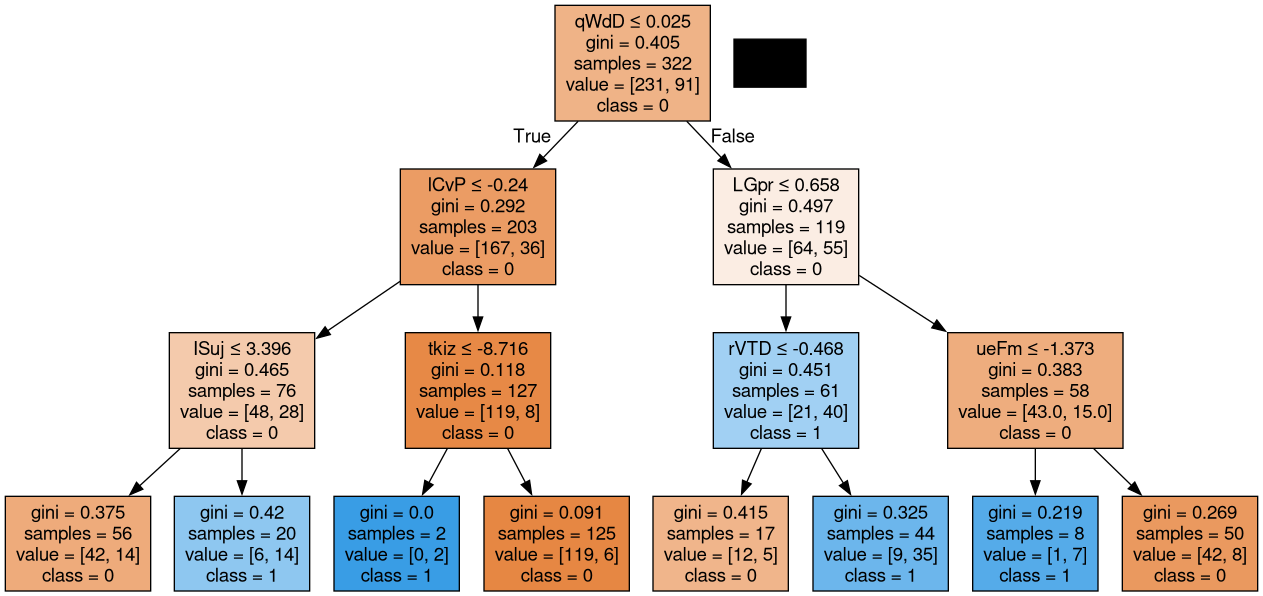

In [9]:
dibujar_arbol(tree_1)

### Ejercicio 2.2

In [10]:
def stratifiedKFoldCV(algoritmo, X_train, y_train, cv):
    resultados_folds = []
    resultados_por_clase = []
    y_global_true = np.empty(len(y_train))
    y_global_pred = np.empty(len(y_train))
    y_global_proba = np.empty(len(y_train)) # El nombre proba es por aucroc devuelve la probabilidad de pertenecer a la clase.

    for fold_idx, (train_index, val_index) in enumerate(cv.split(X_train, y_train)):

        kf_X_train, kf_X_test = X_train.iloc[train_index], X_train.iloc[val_index]
        kf_y_train, kf_y_test = y_train.iloc[train_index], y_train.iloc[val_index]

        algoritmo.fit(kf_X_train, kf_y_train)
        
        y_pred_train = algoritmo.predict(kf_X_train)
        y_pred_test = algoritmo.predict(kf_X_test)

        acc_por_clase = recall_score(y_true=kf_y_test,y_pred=y_pred_test , average=None)
        acc_mayoritaria = round(acc_por_clase[0] * 100, 2)
        acc_minoritaria = round(acc_por_clase[1] * 100, 2)

        # Probabilidad de pertenecer a la clase positiva, buen pronóstico (la minoritaría)
        y_pred_proba_train = algoritmo.predict_proba(kf_X_train)[:, 1]
        y_pred_proba_test = algoritmo.predict_proba(kf_X_test)[:, 1]

        y_global_true[val_index] = kf_y_test
        y_global_pred[val_index] = y_pred_test
        y_global_proba[val_index] = y_pred_proba_test

        resultados_folds.append({
            'Permutación': str(fold_idx),
            'Accuracy (train)': accuracy_score(kf_y_train, y_pred_train),
            'Accuracy (validation)': accuracy_score(kf_y_test, y_pred_test),
            'AUC-PRC (train)': average_precision_score(kf_y_train, y_pred_proba_train),
            'AUC-PRC (validation)': average_precision_score(kf_y_test, y_pred_proba_test),
            'AUC-ROC (train)': roc_auc_score(kf_y_train, y_pred_proba_train),
            'AUC-ROC (validation)': roc_auc_score(kf_y_test, y_pred_proba_test)
        })

        resultados_por_clase.append({
            'Permutación': str(fold_idx),
            'Accuracy (mayoritaria)': acc_mayoritaria,
            'Accuracy (minoritaria)': acc_minoritaria
        })
    df_tabla = pd.DataFrame(resultados_folds)
    df_tabla_clase = pd.DataFrame(resultados_por_clase)

    promedios = df_tabla.drop(columns=['Permutación']).mean()
    df_tabla.loc[len(df_tabla)] = ['Promedios'] + list(promedios)

    df_tabla.loc[len(df_tabla)] = [
        'Global',
        '(NO)',
        accuracy_score(y_global_true, y_global_pred),
        '(NO)',
        average_precision_score(y_global_true, y_global_proba),
        '(NO)',
        roc_auc_score(y_global_true, y_global_proba)
    ]

    return df_tabla, df_tabla_clase, y_global_true, y_global_proba

In [11]:
tree_3 = DecisionTreeClassifier(max_depth=3, random_state=SEED)
X_train, y_train = df.drop(columns=['target']), df['target']

df_resultados_tree_3, _, y_true, y_proba = stratifiedKFoldCV(tree_3, X_train, y_train, stratifiedKFold)

df_resultados_tree_3

,Permutación,Accuracy (train),Accuracy (validation),AUC-PRC (train),AUC-PRC (validation),AUC-ROC (train),AUC-ROC (validation)
0,0,0.825,0.728395,0.688876,0.457783,0.843647,0.720765
1,1,0.841121,0.612500,0.692027,0.353266,0.864142,0.618730
2,2,0.813084,0.687500,0.658068,0.420417,0.846417,0.737069
3,3,0.82866,0.650000,0.70596,0.412458,0.870659,0.670862
4,4,0.831776,0.612500,0.682425,0.372447,0.849254,0.673150
5,Promedios,0.827928,0.658179,0.685471,0.403274,0.854824,0.684115
6,Global,(NO),0.658354,(NO),0.394941,(NO),0.682922


### Ejercicio 2.3

In [12]:
def grid_search_tree(X_train, y_train, param_grid={'max_depth': [3,5,None], 'criterion': ['gini', 'entropy']}, metric='accuracy'):
    grid = ParameterGrid(param_grid)
    res = []
    
    for params in grid:
        current_tree = DecisionTreeClassifier(**params, random_state=SEED)
        
        cv_results = cross_validate(
            current_tree, 
            X_train, 
            y_train, 
            cv=stratifiedKFold, 
            scoring=metric, 
            return_train_score=True 
        )
        
        fila = {}
        for param_name, param_value in params.items():
            if param_name == 'max_depth' and param_value is None:
                fila[param_name] = 'Infinito'
            else:
                fila[param_name] = param_value
                
        fila[f'{metric} (training)'] = cv_results['train_score'].mean()
        fila[f'{metric} (validación)'] = cv_results['test_score'].mean()
        
        res.append(fila)

    return pd.DataFrame(res)

In [13]:
X_train, y_train = df.drop(columns=['target']), df['target']
res_grid_search_tree = grid_search_tree(X_train, y_train)

In [14]:
res_grid_search_tree

,criterion,max_depth,accuracy (training),accuracy (validación)
0,gini,3,0.827928,0.658179
1,gini,5,0.933289,0.683179
2,gini,Infinito,1.000000,0.685710
3,entropy,3,0.803621,0.678241
4,entropy,5,0.885923,0.655741
5,entropy,Infinito,1.000000,0.658148


### Ejercicio 2.4


Clase 0 = Mal Pronóstico = Clase Mayoritaria → NEGATIVA

Clase 1 = Buen Pronósitco = Clase Minoritaria → POSITIVA

Queremos detectar los casos donde la *hiperplasia* evolucionan hacia *tumores malignos*, por eso nos interesan las instancias que tiene un buen pronóstico, ya que son las que poseen cierta predisposición al cáncer pero no lo terminan de desarrollar.

La clase positiva es díficil de clasificar porque hay pocas instancias con las que entrenar el modelo. Esto se ve reflejado en valores muy bajos de AUC-PRC. Ya que el modelo solo mejora recall sacrificando la precision.

Como se ve en el siguiente gráfico:


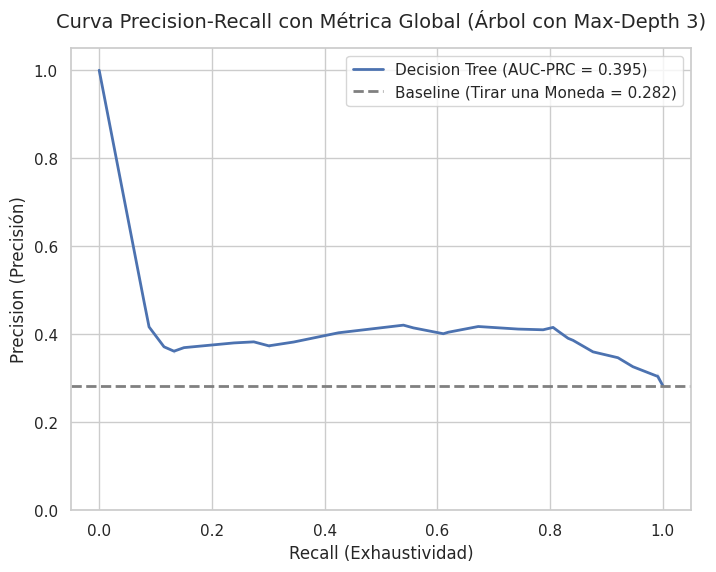

In [15]:
precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
auc_prc_global = average_precision_score(y_true, y_proba)

baseline = y_true.mean()

df_prc = pd.DataFrame({
    'Recall': recall,
    'Precision': precision
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

sns.lineplot(
    data=df_prc, 
    x='Recall', 
    y='Precision', 
    color='b', 
    linewidth=2,
    label=f'Decision Tree (AUC-PRC = {auc_prc_global:.3f})'
)

plt.axhline(y=baseline, color='gray', linestyle='--', linewidth=2, label=f'Baseline (Tirar una Moneda = {baseline:.3f})')

plt.title('Curva Precision-Recall con Métrica Global (Árbol con Max-Depth 3)', fontsize=14, pad=15)
plt.xlabel('Recall (Exhaustividad)', fontsize=12)
plt.ylabel('Precision (Precisión)', fontsize=12)

plt.legend(loc='upper right') 

plt.xlim([-0.05, 1.05])
plt.ylim([0.0, 1.05])

plt.show()

Debido a la escasez de datos de la clase positiva, el modelo no logra aprender a discriminarlas correctamente, a medida que intenta detectar la clase positiva la precisión decae drasticamente al equivocarse con la clase negativa.

En cuanto a la configuración óptima, concluimos que conviene utilizar un árbol de altura 5, ya que ofrece un rendimiento similar a estructuras más profundas pero con un modelo mucho más simple (dejando al índice Gini como una mejor opción solo para árboles más grandes). A pesar de estos ajustes, ningún de los árboles evaluados logra superar la performance de un modelo dummy que predice sistemáticamente la clase mayoritaria.

## Ejercicio 3

In [16]:
# Función para generar una tabla de resultados a partir de un objeto RandomizedSearchCV entrenado
def generar_tabla_resultados(busqueda_entrenada):
    df_resultados = pd.DataFrame(busqueda_entrenada.cv_results_)
    
    columnas_params = [col for col in df_resultados.columns if col.startswith('param_')]
    columnas_metricas = [
        'rank_test_score',
        'mean_test_score',
        'std_test_score'
    ]

    columnas_totales = columnas_metricas + columnas_params
    tabla_limpia = df_resultados[columnas_totales].sort_values(by='rank_test_score')
    
    mapeo_nombres = {col: col.replace('param_', '') for col in columnas_params}
    tabla_limpia = tabla_limpia.rename(columns=mapeo_nombres)

    return tabla_limpia

### Ejercicio 3.1

#### Árboles de Decisión

In [17]:
X_train, y_train = df.drop(columns=['target']), df['target']

random_search_tree = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEED),
    param_distributions={
        'max_depth': [3, 5, 6, 7, None],
        'criterion': ['gini', 'entropy'],
        'max_features' : [None, 'sqrt', 'log2'],
        'min_samples_split' : [15, 20, 25, 30, 35, 40],
    }, # restringe el espacio de búsqueda a estos valores
    n_iter=50, # combinaciones aleatorias a probar
    scoring='roc_auc', # métrica a optimizar
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    n_jobs=-1 # esto permite usar todos los cores de CPU
)

random_search_tree.fit(X_train, y_train)

generar_tabla_resultados(random_search_tree)

,rank_test_score,mean_test_score,std_test_score,min_samples_split,max_features,max_depth,criterion
23,1,0.674666,0.026696,30,None,7,gini
12,2,0.672386,0.027341,25,None,7,gini
38,3,0.671124,0.035511,15,None,5,gini
47,4,0.664803,0.035129,40,None,6,gini
48,5,0.648585,0.063594,40,None,5,gini
8,6,0.643487,0.034897,35,None,None,gini
17,7,0.639852,0.044342,25,None,None,gini
31,8,0.635497,0.045140,40,None,None,entropy
39,9,0.631918,0.042470,30,None,7,entropy
20,10,0.627754,0.039456,15,log2,3,gini


In [18]:
df_resultados_tree, _, _, _ = stratifiedKFoldCV(random_search_tree.best_estimator_, X_train, y_train, stratifiedKFold)

Para Árboles de Decisión decidimos utilizar como hiperparámetros la profundidad máxima (`max_depth`), el criterio de homogeneidad (`criterion`), la cantidad máxima de atributos por corte (`max_features`) y el mínimo de muestras para dividir un nodo (`min_samples_split`).

##### Max Depth
Limitamos los valores entre 2-5 y `None`. El primer rango fue para evitar sobreajustar el árbol, y conservamos la opción `None` como referencia.

##### Min samples split
Pone una cota inferior a la cantidad de muestras que tiene que haber en un nodo para seguir buscando cortes. Elegimos los valores `[15, 20, 25, 30, 35, 40]` debido al tamaño del dataset con 400 instancias y el pequeño porcentaje de instancias de la clase positiva. Valores más pequeños harían que el árbol tarde más en dejar de crecer provocando sobreajuste, mientras que valores más grandes podrian hacer que el arbol se corte antes.

##### Max features
Indica cuántos atributos va a considerar el algoritmo como candidatos a un corte. Elegimos `[None, 'sqrt', 'log2']` por ser las opciones estándar utilizadas. Lo mismo con los criterios en `criterion`, donde se incluyeron `['gini', 'entropy']` que fueron vistos en clase.

##### Resultados
En los resultados del `RandomizedSearchCV` se puede ver que la característica más importante fue setear `max_features` como `None`, lo que le dio libertad al algoritmo de considerar todos los atributos posibles para cada corte.

También, como criterio de corte, `gini` fue el más usado en los estimadores con mejor performance. Esto puede deberse a que Gini prioriza maximizar la pureza del nodo con cortes más estables y representativos ante el desbalance.

No se vieron valores destacados en `min_samples_split` dentro del *topa*, por lo que las conclusiones respecto al mismo podrian ser que no es fundamental para mejorar la performance, aun asi, consideramos que el rango explorado es el adecuado.

##### Mejor configuración encontrada
El mejor estimador obtenido fue:
* `min_samples_split`: 30
* `max_features`: `None`
* `max_depth`: 4
* `criterion`: `gini`

Al correr `stratifiedKFoldCV` con esta combinación de atributos, se obtiene una diferencia de performance en AUC-ROC de 0.202241 entre el set de entrenamiento (0.894169) y el de validación (0.691928). Esta diferencia no tan grande podría deberse a la elección que hicimos en `min_samples_split` y `max_depth` que evito que el árbol memorize el ruido en los datos de entrenamiento.

#### KNN

In [19]:
X_train, y_train = df.drop(columns=['target']), df['target']

random_search_KNN = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions={
        'n_neighbors': range(1,20),
        'weights': ["uniform","distance"],
        'metric':["cityblock","cosine","euclidean"]
    }, 
    n_iter=30, 
    scoring='roc_auc',
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    
)

random_search_KNN.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'metric': ['cityblock', 'cosine', ...], 'n_neighbors': range(1, 20), 'weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",2026
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for 

In [20]:
generar_tabla_resultados(random_search_KNN)

,rank_test_score,mean_test_score,std_test_score,weights,n_neighbors,metric
10,1,0.852107,0.045036,distance,17,cosine
19,2,0.850399,0.051142,distance,19,cosine
12,3,0.847565,0.035866,distance,14,cosine
21,4,0.845835,0.039610,distance,11,cosine
27,5,0.844719,0.043188,uniform,18,cityblock
29,6,0.840749,0.044681,distance,11,cityblock
11,7,0.839794,0.034082,distance,13,cosine
17,8,0.836256,0.046956,uniform,18,cosine
9,9,0.833444,0.032510,distance,4,cosine
5,10,0.832521,0.057691,uniform,19,cosine


##### Hiperparámetros considerados

Elegimos los siguientes hiperparámetros:

- **k (`n_neighbors`)**: para ver cuánto cambia el rendimiento según la cantidad de vecinos.
- **Métrica de distancia**: como los datos están en dimensión alta, todos los puntos están más o menos lejos de todos. Por eso, la forma de medir la distancia podría afectar mucho a quién se considera vecino y a quién no.
- **Pesos (`weights`)**: no es lo mismo tomar k vecinos si algunos están muy cerca según la métrica elegida y otros están muy lejos, pero siguen siendo los más cercanos disponibles. En ese caso, puede convenir dar más importancia a los que están más cerca.

##### Rangos y valores probados

- **k**: usamos de 1 a 30 vecinos. Como solo tenemos 400 instancias, 30 vecinos representan el 7.5% de los datos. Usar más vecinos va a afectar negativamente a la clase positiva.
- **Pesos**: probamos los dos esquemas comunes:
  - considerar todos los vecinos por igual (`uniform`);
  - ponderar según la distancia (`distance`).
- **Métrica**: usamos `d1` (Manhattan/cityblock), `d2` (Euclídea) y distancia coseno, que suele funcionar bien en dimensiones altas.
- **Número de iteraciones**: usamos 50, ya que el total de posibilidades es 180. Creemos que cambiar pocos vecinos afectaría poco el resultado.

##### Resultados

Viendo las primeras 10 mejores combinaciones:

- Todas tienen un promedio de puntaje parecido, que va de **0.84 a 0.85**.
- Las desviaciones estándar van de **0.07 a 0.03**.
- De las 10 mejores combinaciones, **8 usaron peso por distancia**. Es decir, sirvió tener en cuenta qué tan lejos están los vecinos para decidir.
- El número de vecinos estuvo entre **16 y 23**, lo que indica que usar pocos vecinos es relativamente malo.
- Las métricas fueron **d1 o coseno**. `d2` no se usó, lo cual tiene sentido, ya que `d2` no es buena en dimensiones altas.

##### Conclusión

Como las mejores combinaciones se parecen mucho —la mayoría usa la 
distancia para pesar, los vecinos están más o menos en las mismas cantidades **¿qué significa cantidades?** y la métrica es `d1` o coseno—, la mejor combinación parece depender más de los datos que de los parámetros.

##### Mejor combinación encontrada

| mean_test_score | std_test_score | weights  | n_neighbors | metric    |
|-----------------|----------------|----------|-------------|-----------|
| 0.854821        | 0.037292       | distance | 21          | cityblock |

#### SVM

In [21]:
def mejor_SVC_dado_df(X_train, y_train):
    param_dist = [
        {
            'svc__estimator__kernel': ['rbf'],
            'svc__estimator__C': np.logspace(-3, 3, 7), # [0.001, 0.01, 0.1, 1, 10, 100, 1000]
            'svc__estimator__gamma': list(np.logspace(-4, 1, 6)) + ['scale', 'auto'], # [0.001, 0.01, 0.1, 1, 10]
        },
        {
            'svc__estimator__kernel': ['poly'],
            'svc__estimator__C': np.logspace(-3, 3, 7),
            'svc__estimator__gamma': list(np.logspace(-4, 1, 6)) + ['scale', 'auto'],
            'svc__estimator__degree': [2,3,5],
            'svc__estimator__coef0': [0.0, 0.1, 0.5],
        },
        {
            'svc__estimator__kernel': ['linear'],
            'svc__estimator__C': np.logspace(-3, 3, 7),
        },
]

    pipe = Pipeline([
        # Escalar para evitar problema de magnitudes diferentes entre features
        ('scaler', StandardScaler()),
        ('svc', CalibratedClassifierCV(SVC(), ensemble=False, cv=5))
    ])

    random_search_svc = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=50,
        scoring='roc_auc',
        cv=stratifiedKFold,
        random_state=SEED,
        n_jobs=-1
    )
    
    random_search_svc.fit(X_train, y_train)
    return random_search_svc

In [22]:
random_search_svc = mejor_SVC_dado_df(X_train, y_train)
random_search_svc.best_params_

{'svc__estimator__kernel': 'poly',
 'svc__estimator__gamma': np.float64(0.01),
 'svc__estimator__degree': 3,
 'svc__estimator__coef0': 0.1,
 'svc__estimator__C': np.float64(0.1)}

In [23]:
generar_tabla_resultados(random_search_svc)

,rank_test_score,mean_test_score,std_test_score,svc__estimator__kernel,svc__estimator__gamma,svc__estimator__degree,svc__estimator__coef0,svc__estimator__C
24,1,0.815141,0.036299,poly,0.01,3.0,0.1,0.100
2,2,0.814491,0.044131,poly,0.01,5.0,0.5,10.000
29,3,0.811253,0.039173,poly,auto,5.0,0.1,0.100
36,4,0.801006,0.042039,poly,auto,2.0,0.1,10.000
34,5,0.796838,0.044138,poly,auto,2.0,0.1,0.010
5,6,0.795149,0.039565,poly,0.1,3.0,0.5,0.001
16,7,0.790870,0.053708,poly,scale,5.0,0.5,1000.000
49,7,0.790870,0.053708,poly,auto,5.0,0.5,100.000
20,9,0.789930,0.041880,poly,0.01,5.0,0.1,100.000
11,10,0.769582,0.058869,poly,0.1,2.0,0.1,1.000


In [24]:
df_resultados_svc, df_resultados_clase_svc, _, _ = stratifiedKFoldCV(random_search_svc.best_estimator_, X_train, y_train, stratifiedKFold)

df_resultados_svc

,Permutación,Accuracy (train),Accuracy (validation),AUC-PRC (train),AUC-PRC (validation),AUC-ROC (train),AUC-ROC (validation)
0,0,1.0,0.777778,1.0,0.622561,1.0,0.805097
1,1,1.0,0.787500,1.0,0.693951,1.0,0.821317
2,2,1.0,0.750000,1.0,0.590268,1.0,0.829154
3,3,1.0,0.725000,1.0,0.570045,1.0,0.754386
4,4,1.0,0.825000,1.0,0.810895,1.0,0.865751
5,Promedios,1.0,0.773056,1.0,0.657544,1.0,0.815141
6,Global,(NO),0.773067,(NO),0.629647,(NO),0.810749


In [25]:
df_resultados_clase_svc

,Permutación,Accuracy (mayoritaria),Accuracy (minoritaria)
0,0,87.93,52.17
1,1,87.93,54.55
2,2,91.38,31.82
3,3,85.96,39.13
4,4,100.00,39.13


In [26]:
metricas_svc, metricas_clases_svc, _, _ = stratifiedKFoldCV(random_search_svc.best_estimator_, X_train, y_train, stratifiedKFold)

In [27]:
metricas_svc

,Permutación,Accuracy (train),Accuracy (validation),AUC-PRC (train),AUC-PRC (validation),AUC-ROC (train),AUC-ROC (validation)
0,0,1.0,0.777778,1.0,0.622561,1.0,0.805097
1,1,1.0,0.787500,1.0,0.693951,1.0,0.821317
2,2,1.0,0.750000,1.0,0.590268,1.0,0.829154
3,3,1.0,0.725000,1.0,0.570045,1.0,0.754386
4,4,1.0,0.825000,1.0,0.810895,1.0,0.865751
5,Promedios,1.0,0.773056,1.0,0.657544,1.0,0.815141
6,Global,(NO),0.773067,(NO),0.629647,(NO),0.810749


##### Hiperparámetros

**Para todos los kernels: C**

Parámetro de regularización, controla la penalización sobre la suma del margen de error total de las instancias en la clasficación. Mientras más grande mayor es la penalización sobre los errores. Con respecto a las fronteras de decisión mientras mayor sea el valor las fronteras serán más complejas y/o estrechas y los errores durante el entrenamiento serán menores (puede generar overfitting).
Un valor adecuedo permite errores en entrenamiento a cambio de aumentar la capacidad de generalización y robustez del modelo, al hacerlo menos sensible durante entrenamiento a instancias individuales. 
El rango de exploración es amplio y en escala logaritmica, ya que el impacto no es lineal en la performance del algoritmo.

**Para RBF y Polynomial: Gamma γ**

Determina el radio de influencia de cada vector de soporte por separado.
A medida que se aumenta γ la similitud entre dos instancias disminuye más rápidamente con la distancia.
Esto permite que se capturen fronteras de decisión cada vez más complejas, ya que dependen de localidades de instancias más pequeñas. Pueden formarse "islas".
Intuitivamente, define la forma (complejidad inicial) de la frontera de decisión. A medida que el valor de C aumenta se acentúa la forma de la frontera.
El rango de exploración es similar al de C, pero con valores máximos menores, para evitar overfitting.

**Para polinomial: Degree**

Determina la dimensión del espacio donde se busca el hiperplano, al crear "nuevos atributos" a partir de combinaciones de los originales. El grado determina la complejidad de esas transformaciones y cuantas combinaciones se tienen en cuenta. También depende de coef0, ya que si es 0 solo se tienen en cuenta combinaciones de grado exactamente d (por ejemplo d atributos distintos multiplicados).
A medida que aumenta d aumenta la complejidad de la frontera de decisión, por ejemplo con d = 2 la frontera puede ser una elipse o parábola, mientras que con d = 3 formas más complejas como el [tridente de Newton](https://es.wikipedia.org/wiki/Tridente_de_Newton).
La desventaja es el aumento en la complejidad computacional y riesgo de overfitting para grados muy altos o inadecuados dada la distribución de las instancias dadas las clases.
La elección de grados pequeños se debe al costo computacional, y a que al elegir RBF fronteras muy complejas ya se tienen en cuenta.

**Coeficiente de grado 0**

Controla si existen y el peso de los nuevos atributos (monomios) de grado estrictamente menor a d.
Permite tener en cuenta relaciones más simples, como las lineales, para el hiperplano (y por lo tanto la frontera de decisión) 
Los valores elegidos son los estándar, no tenemos conocimiento alguno del tipo y la cantidad de relaciones entre los atributos que hay. 

**Kernels**

El kernel lineal fue elegido inicialmente y por los malos resultados y desconocimiento del tipo de frontera de decisión añadimos kernels no lineales al espacio de búsqueda, con diversidad en la complejidad en las fronteras que pueden definir. 

- **RBF (Radial Basis Function):** Para clasificar x pondera las instancias cercanas para calcular P(x), con P el plano. Supone que el signo de x depende, justamente, de las instancias más cercanas. Mapea los datos a un espacio de dimensión infinita, lo que permite hiperplanos de decisión muy complejas. Esto lo hace propenso al overfitting si no se calibran bien otro hiperparámetros.

- **Linear:** Estándar. Solo útil cuando las instancias son linealmente separable.

- **Polinomial:** Permite fronteras de decisión más flexibles, pero limitadas. Útil cuando se tiene conocimiento previo del tipo de frontera de decisión. La desventaja es que es costoso, ya que la dimensión del espacio crece exponencialmente a medida que aumenta el grado del kernel. 

**Resultados**

De un espacio de buscado de 497 configuraciones se realizaron 50 iteraciones.
La mejor combinación es: 
| kernel | gamma | degree | coef0 | C |
|--------|-------|--------|-------|---|
| poly | 0.01 | 3 | 0.1 | 0.1 |


Y el top 10 de mejores modelos (según AUCROC) también son polinomiales, todos tienen un valor de gamma bajo pero un valor de C muy variable. Deberíamos hacer más pruebas para poder explicar esta variación en este último parámetro

### Ejercicio 3.2

#### LDA

In [28]:
X_train, y_train = df.drop(columns=['target']), df['target']
lda_model = LinearDiscriminantAnalysis()

resultados_lda = cross_validate(
    lda_model,
    X_train,
    y_train,
    cv=stratifiedKFold,
    scoring='roc_auc'
)

aucroc_promedio_nb = resultados_lda['test_score'].mean()
print(f"AUCROC promedio de LDA: {aucroc_promedio_nb:.4f}")

AUCROC promedio de LDA: 0.6265


#### Naive Bayes

In [29]:
X_train, y_train = df.drop(columns=['target']), df['target']
nb_model = GaussianNB()

resultados_nb = cross_validate(
    nb_model, 
    X_train,
    y_train, 
    cv=stratifiedKFold, 
    scoring='roc_auc'
)

aucroc_promedio_nb = resultados_nb['test_score'].mean()
print(f"AUCROC promedio de Naïve Bayes (Default): {aucroc_promedio_nb:.4f}")

AUCROC promedio de Naïve Bayes (Default): 0.7291


Respecto a los hiperparámetros:

El rendimiento de *LDA (Linear Discriminant Analysis)* se ve fuertemente limitado por la alta dimensionalidad de los datos (200 columnas vs. 400 filas). Esta proporción dificulta el cálculo interno para estimar la matriz de covarianzas, volviéndola inestable y provocando que el modelo tienda al overfitting. 

Para mitigar este problema, podríamos explorar los siguientes hiperparámetros:

##### Shrinkage
Este hiperparámetro soluciona la inestabilidad de los cálculos al asumir estadísticamente que los atributos son "más" independientes entre sí. Para nuestro dataset, esto podría ser útil porque ayuda a ignorar las "relaciones falsas" que suelen aparecer cuando tenemos pocos datos para la cantidad de atributos que tenemos, logrando así que el modelo sea más estable y generalice mejor. Sin embargo, al forzar esta independencia, el modelo también pierde de vista las correlaciones reales. Como nuestro objetivo es detectar diferencias muy sutiles, aplicar en exceso este ajuste (que actua como regularización) podría terminar "borrando" los patrones e interacciones que necesitamos para distinguir correctamente a qué clase pertenece cada instancia.

##### Solver
La exploración de este hiperparámetro es un requisito técnico para poder implementar la técnica de regularización anterior. El solucionador utilizado por defecto ('svd') no es compatible con el cálculo del shrinkage, por lo que es obligatorio modificar el espacio de búsqueda hacia los algoritmos 'lsqr' (mínimos cuadrados) o 'eigen' (descomposición en autovalores). Ajustar este parámetro es lo que finalmente viabiliza la estabilización de la matriz, permitiéndonos evaluar empíricamente si la reducción del ruido matemático logra superar a la pérdida de información en las correlaciones complejas.

Gaussian Naive Bayes cuenta con únicamente dos hiperparámetros para configurar:

##### Priors
Permite definir manualmente las probabilidades a priori de cada clase. En nuestro dataset (fuertemente desbalanceado y con diferencias sutiles entre las distribuciones dada la clase), el modelo por defecto tiende a sesgarse hacia la clase mayoritaria. Forzar priors equilibradas anula este sesgo, obligando al algoritmo a decidir basándose exclusivamente en las distribuciones dada la clase de los atributos. Como contrapartida, esto modifica arbitrariamente la distribución real de los datos, donde no sabemos con exactitud la proporción de clases.

##### Var Smoothing
Aunque en nuestros datos no hay varianzas nulas (cercanas a cero), este parámetro actúa como un mecanismo de regularización. Al aumentar su valor, se ensanchan artificialmente las campanas de Gauss de cada atributo. Esto suaviza las fronteras de decisión y previene el overfitting al ruido que pueda haber en el dataset. Sin embargo, alterar la varianza original para forzar la estabilidad introduce un sesgo intencional.

### Ejercicio 3.3 - Mejor Modelo

El mejor modelo fue SVC con la siguiente configuración:
| kernel | gamma | degree | coef0 | C |
|--------|-------|--------|-------|---|
| poly | 0.01 | 3 | 0.1 | 0.1 |

Creemos que es el mejor, en primer lugar, porque las fronteras de decisión no son lineales (por lo tanto tiene ventaja frente a LDA y Árboles).
Luego, creemos que existe alguna correlación entre los atributos, sobre todo para la clase positiva, por la naturaleza de los datos. Esta correlación no la podemos justificar a partir de los datos ni a través de test estadísticos, solo por los resultados en comparación a Naive Bayes y KNN, ya que para la clase negativa tenemos un recall idéntico, mientra que para la positiva hay aprox. 0.25 puntos de diferencia (por eso AUCROC es más alto).

In [30]:
def evaluar_modelos_en_control(modelos, X_train, y_train, X_control, y_control):
    resultados = []

    for nombre_modelo, modelo in modelos.items():     
        modelo.fit(X_train, y_train)
        y_pred_control = modelo.predict(X_control)
        y_pred_proba_control = modelo.predict_proba(X_control)[:, 1]

        acc_por_clase = recall_score(y_control, y_pred_control, average=None)
        acc_mayoritaria = round(acc_por_clase[0] * 100, 2)
        acc_minoritaria = round(acc_por_clase[1] * 100, 2)

        resultados.append({
            'Modelo': str(nombre_modelo),
            'Accuracy (control)': accuracy_score(y_control, y_pred_control),
            'Accuracy Mayoritaria (control)': acc_mayoritaria,
            'Accuracy Minoritaria (control)': acc_minoritaria,
            'AUC-PRC (control)': average_precision_score(y_control, y_pred_proba_control),
            'AUC-ROC (control)': roc_auc_score(y_control, y_pred_proba_control)
        })

    return pd.DataFrame(resultados)

In [31]:
X_train, y_train = df.drop(columns=['target']), df['target']
X_control, y_control = df_control.drop(columns=['target']), df_control['target']

# El mejor tiene hiperparametros:min_samples_split = 4, max_features = 'log2', criterion = 'gini', max_depth = 3
# Con un score en kfold de 0.642855
mejor_arbol = random_search_tree.best_estimator_
# El mejor knn tiene hiperparametros: weights= 'distance', n_neighbors = 4, metric = 'cosine'
# Con un score en kfold de 0.832651
mejor_knn = random_search_KNN.best_estimator_

# El mejor SVM tiene hiperparametros: kernel = 'rbf', C=10
# Con un score en kfold de 0.861414
mejor_svm = random_search_svc.best_estimator_

#Agregamos tambien a la comparacion los modelos estandar de LDA y Naive Bayes
nb = GaussianNB()
lda = LinearDiscriminantAnalysis()

modelos = {
    "Mejor Arbol": mejor_arbol,
    "Mejor KNN": mejor_knn,
    "Mejor SVM": mejor_svm,
    "LDA": lda,
    "Naive Bayes": nb
}

df_mejor_modelo = evaluar_modelos_en_control(modelos, X_train, y_train, X_control, y_control)

In [32]:
df_mejor_modelo

,Modelo,Accuracy (control),Accuracy Mayoritaria (control),Accuracy Minoritaria (control),AUC-PRC (control),AUC-ROC (control)
0,Mejor Arbol,0.666667,76.06,42.86,0.382122,0.647636
1,Mejor KNN,0.757576,97.18,21.43,0.651182,0.843561
2,Mejor SVM,0.797980,88.73,57.14,0.684232,0.790744
3,LDA,0.616162,73.24,32.14,0.373255,0.578974
4,Naive Bayes,0.737374,87.32,39.29,0.613338,0.768109


In [33]:
df_mejor_modelo.to_csv('df_mejor_modelo.csv')

#### Mejor Modelo Reentrenado con todos los Datos

In [35]:
X_train, y_train = df_completo.drop(columns=['target']), df_completo['target']
mejor_svc = random_search_svc.best_estimator_

# Lo entrenas con tus datos
mejor_svc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](200,)","['rTjs','Sgqo','egGJ',...,'QDQf','TPVx','FbdX']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,200
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Ejercicio 4

In [ ]:
df_control_externo = pd.read_csv('data_control.csv')

In [ ]:
X_control, y_control = df_control_externo.drop('target', axis=1), df_control_externo['target']

y_pred_proba = mejor_svc.predict_proba(X_control)[:, 1]

auc_roc_control = roc_auc_score(y_control, y_pred_proba)

print(f"El valor estimado de AUC-ROC de Mejor Modelo sobre los datos de control externo es: {auc_roc_control:.4f}")

In [ ]:
fpr, tpr, thresholds = roc_curve(y_control, y_pred_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'SVM Calibrado (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.500)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Evaluación en Conjunto de Control', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()

In [ ]:
auc_roc_truncado = f"{auc_roc_control:.4f}".split('.')[1]

nombre_archivo = f"09_y_pred_control_{auc_roc_truncado}.csv"

df_auc_roc_truncado = pd.DataFrame({'output': y_pred_proba})

df_auc_roc_truncado.to_csv(nombre_archivo, index=False)

## Extras: Análisis de los Datos

### Análisis de Correlación

#### Correlación sin condicionar por Clase

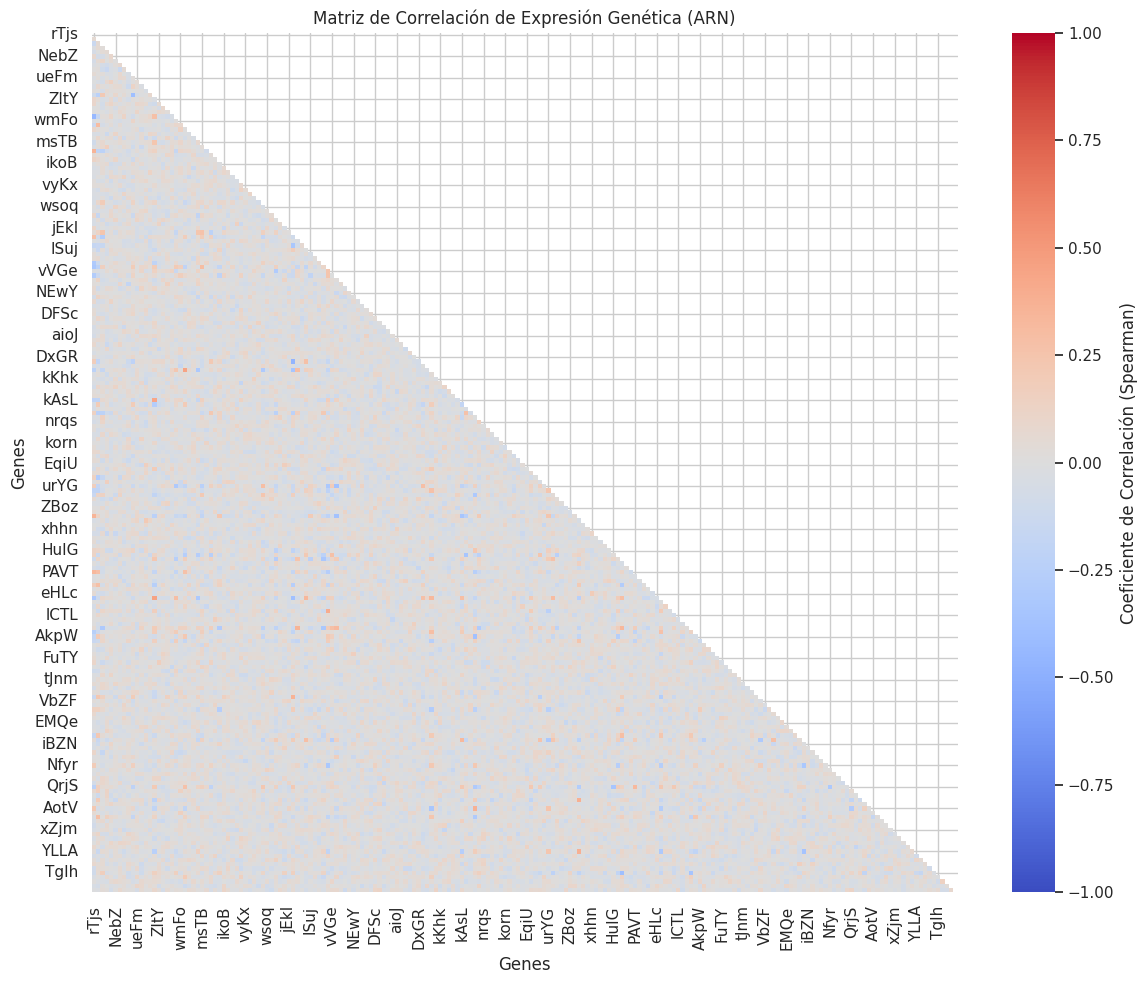

Series([], dtype: float64)


In [37]:
X = df.drop(columns=['target'])

matriz_corr = X.corr(method='spearman')

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_corr, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)
plt.title('Matriz de Correlación de Expresión Genética (ARN)')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
correlaciones_apiladas = matriz_corr.mask(mask).stack()
correlaciones_fuertes = correlaciones_apiladas[abs(correlaciones_apiladas) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes) # Qué gen tiene una correlación marcada.

#### Correlación dada la Clase

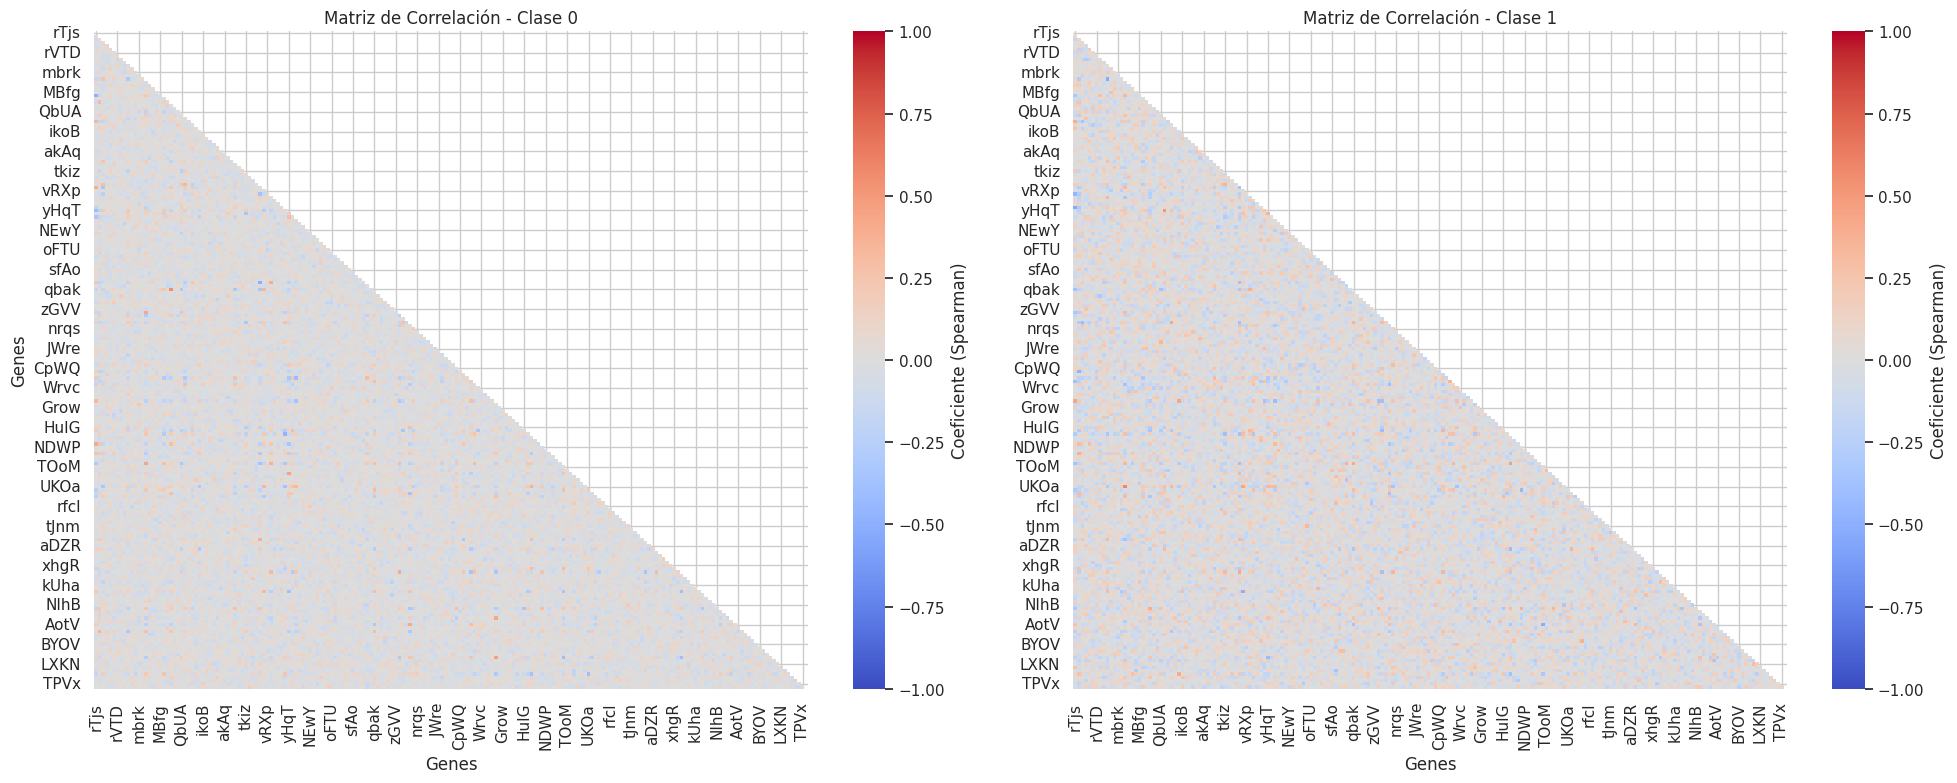

Genes con correlación fuerte en Clase 0:
Series([], dtype: float64)

Genes con correlación fuerte en Clase 1:
Series([], dtype: float64)


In [38]:
X_0 = df[df['target'] == 0].drop(columns=['target'])
X_1 = df[df['target'] == 1].drop(columns=['target'])

corr_0 = X_0.corr(method='spearman')
corr_1 = X_1.corr(method='spearman')

mask = np.triu(np.ones_like(corr_0, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    corr_0, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    ax=axes[0],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[0].set_title('Matriz de Correlación - Clase 0')
axes[0].set_xlabel('Genes')
axes[0].set_ylabel('Genes')

sns.heatmap(
    corr_1, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    ax=axes[1],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[1].set_title('Matriz de Correlación - Clase 1')
axes[1].set_xlabel('Genes')
axes[1].set_ylabel('') 

plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
print("Genes con correlación fuerte en Clase 0:")
correlaciones_apiladas_0 = corr_0.mask(mask).stack()
correlaciones_fuertes_0 = correlaciones_apiladas_0[abs(correlaciones_apiladas_0) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_0)

print("\nGenes con correlación fuerte en Clase 1:")
correlaciones_apiladas_1 = corr_1.mask(mask).stack()
correlaciones_fuertes_1 = correlaciones_apiladas_1[abs(correlaciones_apiladas_1) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_1)

### Análisis de Normalidad en los Atributos dada la Clase

In [39]:
resultados_condicionales = []

for clase in [0, 1]:
    df_clase = df[df['target'] == clase].drop(columns=['target'])
    
    for gen in df_clase.columns:
        data = df_clase[gen].dropna()
        
        _, p_shapiro = shapiro(data)
        es_normal_shapiro = p_shapiro > 0.05
             
        resultados_condicionales.append({
            'Clase': clase,
            'Gen': gen,
            'p_valor_Shapiro': p_shapiro,
            'Normal_Shapiro': es_normal_shapiro,
        })

df_tests_condicional = pd.DataFrame(resultados_condicionales)

display(df_tests_condicional.sort_values(by=['Clase', 'p_valor_Shapiro'], ascending=[True, True]).head(15))

,Clase,Gen,p_valor_Shapiro,Normal_Shapiro
19,0,Jbcl,0.000274,False
23,0,NtjU,0.001213,False
73,0,cvxh,0.002031,False
12,0,mbrk,0.009235,False
28,0,xDHG,0.012950,False
77,0,qHhS,0.021887,False
122,0,GLoy,0.022820,False
130,0,eHLc,0.031694,False
101,0,SZxQ,0.031777,False
65,0,DFSc,0.033604,False


#### Histogramas de Atributos dada la Clase

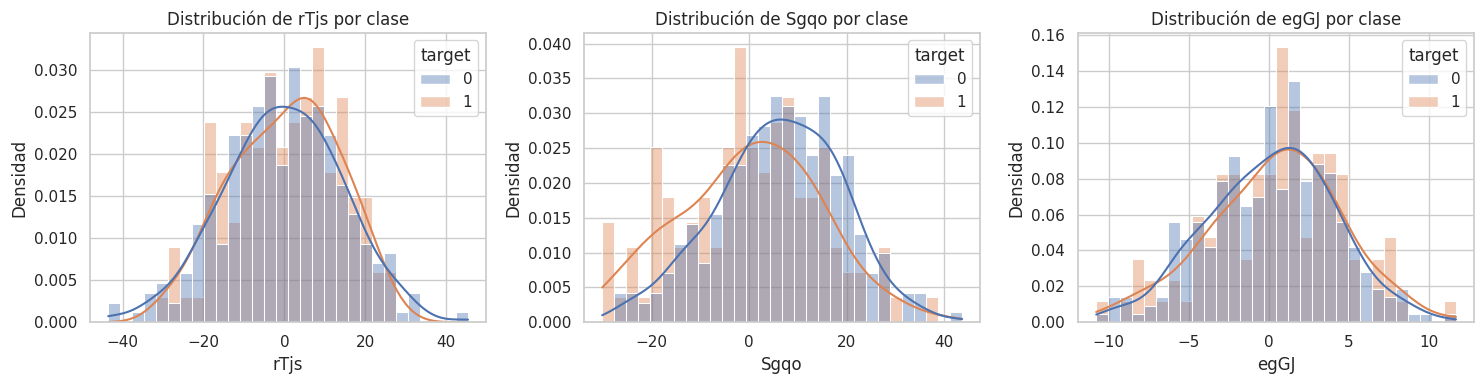

In [45]:
features = [col for col in df.columns if col != 'target']
features = features[:3]#cantidad de genes a graficar

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue='target',
        kde=True,
        stat="density",
        common_norm=False,
        bins=30,
        alpha=0.4,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {feature} por clase")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Densidad")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### OutLiers de las Distribuciones de los Atributos dada la Clase

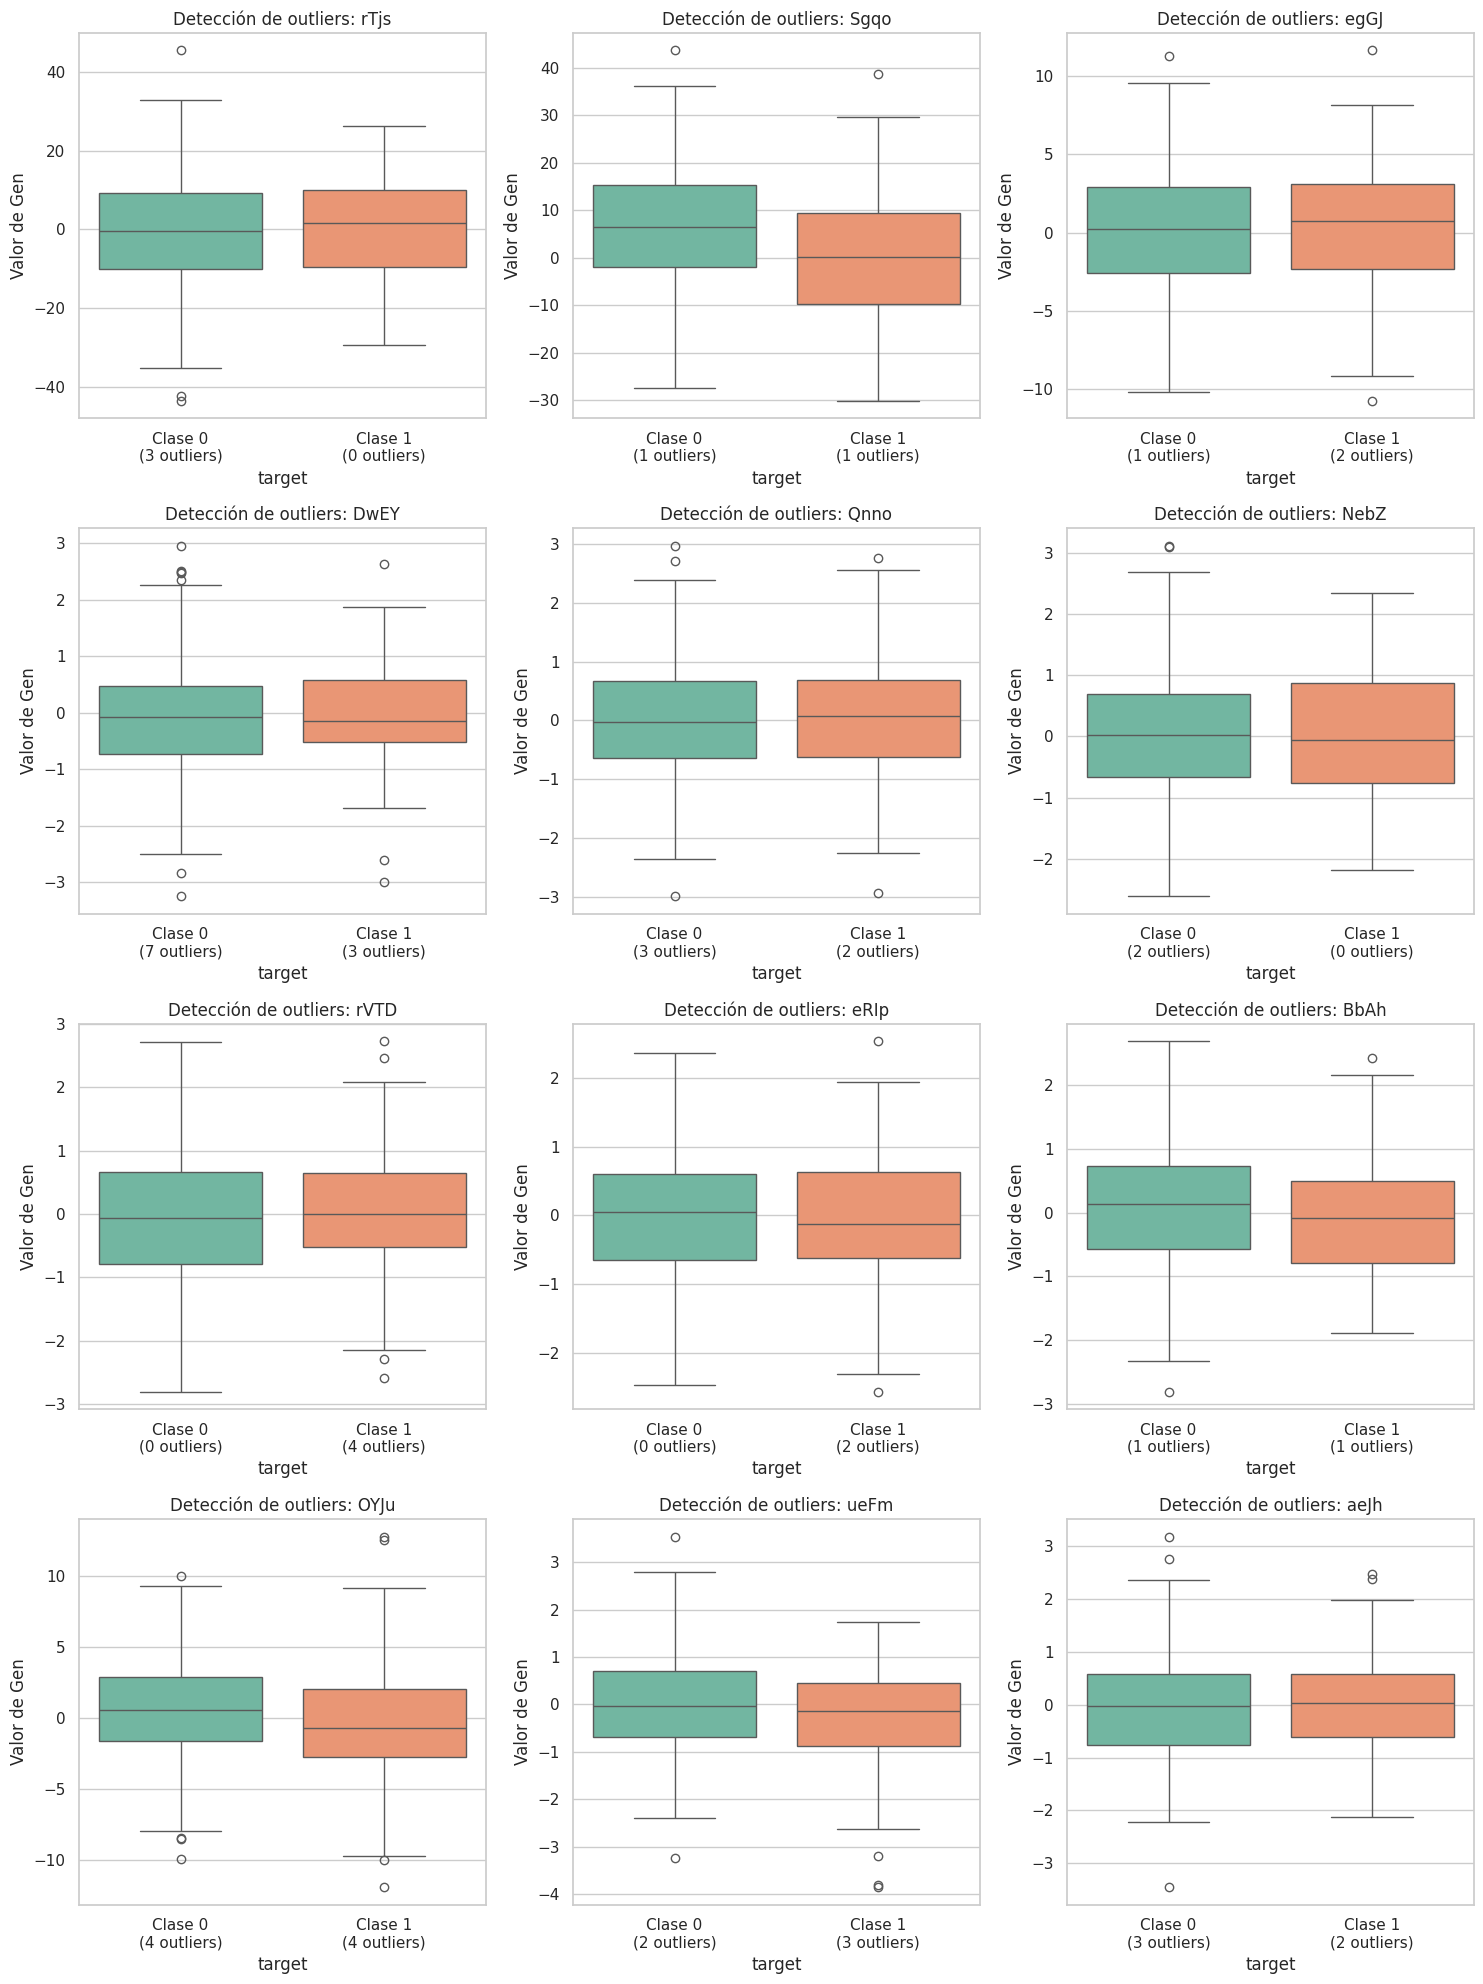

In [51]:
features = [col for col in df.columns if col != 'target'][:12] 

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='target',
        y=feature,
        hue='target',
        legend=False,
        palette="Set2",
        order=[0, 1],
        ax=axes[i]
    )
    
    axes[i].set_title(f"Detección de outliers: {feature}")
    axes[i].set_ylabel("Valor de Gen")
    
    nuevas_etiquetas = []
    
    for clase in [0, 1]:
        datos_clase = df[df['target'] == clase][feature]
    
        Q1 = datos_clase.quantile(0.25)
        Q3 = datos_clase.quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        cantidad_outliers = datos_clase[(datos_clase < limite_inferior) | (datos_clase > limite_superior)].count()
        
        nuevas_etiquetas.append(f"Clase {clase}\n({cantidad_outliers} outliers)")
        
    axes[i].set_xticks(range(2))
    axes[i].set_xticklabels(nuevas_etiquetas)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Análisis de Normalidad Multivariable dada la Clase

In [41]:
def tests_multivariables(df, nombre_dataset="Dataset", target_col='target'):
   
    print(f"RESULTADOS PARA: {nombre_dataset}")
    print("-" * 50)
    
    X_clase_0 = df[df[target_col] == 0].drop(columns=[target_col])
    X_clase_1 = df[df[target_col] == 1].drop(columns=[target_col])
    
    mvn_0 = pg.multivariate_normality(X_clase_0)
    mvn_1 = pg.multivariate_normality(X_clase_1)
    
    print("Test de Normalidad Multivariable (Henze-Zirkler):")
    print(f"Clase 0 -> Normal: {mvn_0.normal} | p-valor: {mvn_0.pval}")
    print(f"Clase 1 -> Normal: {mvn_1.normal} | p-valor: {mvn_1.pval}\n")
    
    lista_genes = df.drop(columns=[target_col]).columns.tolist()
    
    try:
        res_box = pg.box_m(df, dvs=lista_genes, group=target_col)
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"Matrices iguales: {res_box['equal_cov'].iloc[0]} | p-valor: {res_box['pval'].iloc[0]}")
        display(res_box)
    except Exception as e:
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"ERROR MATEMÁTICO: {e}")
        
    print("=" * 60, "\n")

In [42]:
tests_multivariables(df, nombre_dataset="Dataset de Desarrollo", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: False | p-valor: 0.0
Clase 1 -> Normal: False | p-valor: 0.0

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: nan


/opt/miniconda3/lib/python3.13/site-packages/pingouin/multivariate.py:372: RuntimeWarning: invalid value encountered in power
  M = ((np.linalg.det(covs) / S_det) ** (v / 2)).prod()


,Chi2,df,pval,equal_cov
box,NaN,20100.0,NaN,False


No tiene sentido realizar este test al tener solo 400 datos para 200 atributos. Para calcular la matriz de covarianza de 200 variables se necesitarían estimar unas 20 mil relaciones cruzadas, por lo cual no hay suficientes datos para calcularla de manera estable.   

Sin embargo, si discriminamos por aquellos atributos que tienen la mayor varianza entre las medias de sus distribuciones dada la clase, entonces el test puede brindarnos información sobre qué esta pasando. Resulta ser que de esta manera una de las distribuciones dada la clase si es una Normal Multivariable.  

In [43]:
medias = df.groupby('target').mean()
separacion = medias.var()
atributos_top = separacion.nlargest(40).index.tolist()

df_medias = df[atributos_top + ['target']].copy()

tests_multivariables(df_medias, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos)", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo (Top 40 Atributos)
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: False | p-valor: 2.964260264799869e-07
Clase 1 -> Normal: True | p-valor: 0.2803911091787315

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 0.0


/opt/miniconda3/lib/python3.13/site-packages/pingouin/multivariate.py:386: RuntimeWarning: divide by zero encountered in log
  u = -2 * (1 - c) * np.log(M)


,Chi2,df,pval,equal_cov
box,inf,820.0,0.0,False


El método inicial solo evaluaba la distancia entre las medias. Para mejorar la selección, es necesario ponderar la importancia de cada atributo penalizando por su varianza. Este enfoque es, en esencia, el Análisis de Varianza (ANOVA).

In [44]:
X = df.drop(columns=['target'])
y = df['target']
k_mejores = 40

selector = SelectKBest(score_func=f_classif, k=k_mejores)
selector.fit(X, y)

atributos_top = X.columns[selector.get_support()].tolist()

df_anova = df[atributos_top + ['target']].copy()

tests_multivariables(df_anova, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos - ANOVA)", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo (Top 40 Atributos - ANOVA)
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: True | p-valor: 0.38680413539578484
Clase 1 -> Normal: True | p-valor: 0.1852469758149603

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 5.256428804252458e-13


,Chi2,df,pval,equal_cov
box,1142.456667,820.0,5.256429e-13,False


### Modelos Filtrando Atributos

Siguiendo la idea anterior, probamos nuevos modelos variando la cantidad de atributos filtrados.

In [ ]:
# Modelos ya había sido definido previamente, ahora agregamos QDA con regularización
# Antes QDA con tantos atributos y pocos datos fallaba al aproximar la matriz de covarianza
modelos["QDA"] = QuadraticDiscriminantAnalysis(reg_param=0.01)

In [ ]:
def evaluar_modelos_por_medias(separacion, y, modelos, cv, k_min=1, k_max=49):
    resultados = []

    for k in range(k_min, k_max + 1):
        atributos_top = separacion.nlargest(k).index.tolist()
        X_filtrado = df[atributos_top]

        for nombre_modelo, modelo in modelos.items():
            resultados_nb = cross_validate(
                modelo,
                X_filtrado,
                y,
                cv=cv,
                scoring=['roc_auc', 'accuracy']
            )

            resultados.append({
                'k': k,
                'Modelo': nombre_modelo,
                'AUCROC': resultados_nb['test_roc_auc'].mean(),
                'Accuracy': resultados_nb['test_accuracy'].mean()
            })

    return pd.DataFrame(resultados)

medias = df.groupby('target').mean()
separacion = medias.var()
y = df['target']

df_scores_medias = evaluar_modelos_por_medias(separacion, y, modelos, stratifiedKFold, k_min=1, k_max=50)

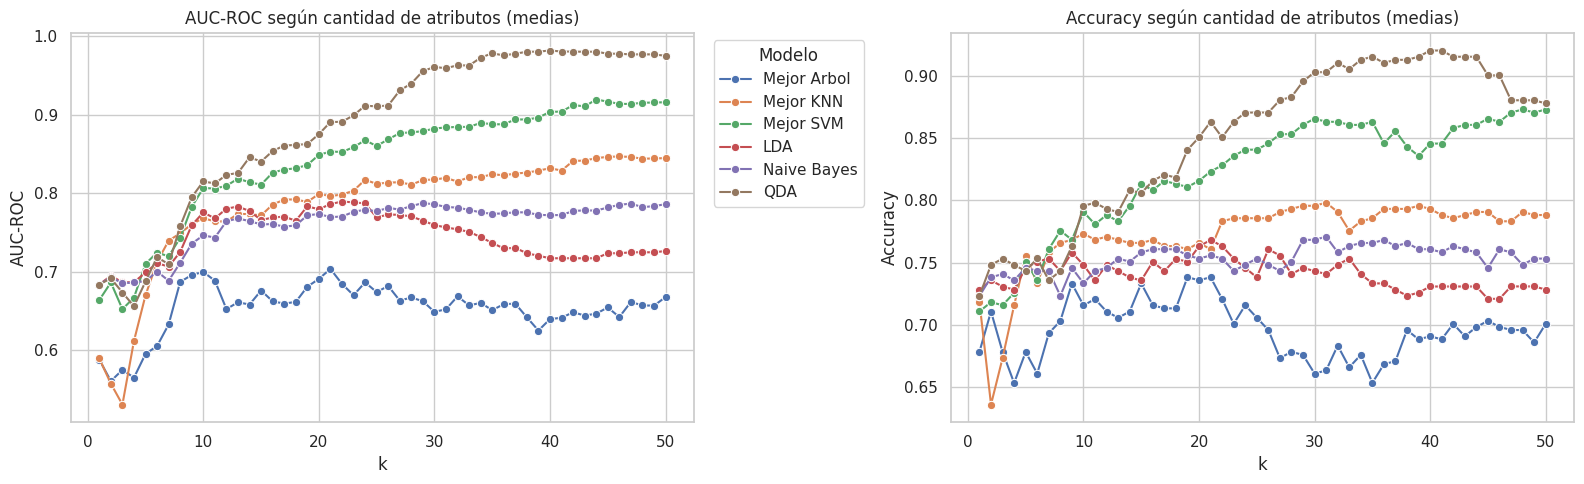

In [ ]:
df_plot = df_scores_medias.melt(id_vars=['k', 'Modelo'], value_vars=['AUCROC', 'Accuracy'], var_name='Metrica', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

sns.lineplot(
    data=df_plot[df_plot['Metrica'] == 'AUCROC'],
    x='k',
    y='Score',
    hue='Modelo',
    marker='o',
    ax=axes[0]
 )
axes[0].set_title('AUC-ROC según cantidad de atributos (medias)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('AUC-ROC')

sns.lineplot(
    data=df_plot[df_plot['Metrica'] == 'Accuracy'],
    x='k',
    y='Score',
    hue='Modelo',
    marker='o',
    ax=axes[1]
 )
axes[1].set_title('Accuracy según cantidad de atributos (medias)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Accuracy')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend_.remove()
axes[0].legend(handles, labels, title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
mejor_fila_medias = df_scores_medias.loc[df_scores_medias['AUCROC'].idxmax()]
mejor_k_medias = int(mejor_fila_medias['k'])

atributos_seleccionados_medias = separacion.nlargest(mejor_k_medias).index.tolist()
X_train_medias = df[atributos_seleccionados_medias]
X_control_medias = df_control[atributos_seleccionados_medias]

df_mejor_modelo_medias = evaluar_modelos_en_control(
    modelos,
    X_train_medias,
    y,
    X_control_medias,
    df_control['target']
)

df_mejor_modelo_medias

,Modelo,Accuracy (control),Accuracy Mayoritaria (control),Accuracy Minoritaria (control),AUC-PRC (control),AUC-ROC (control)
0,Mejor Arbol,0.636364,70.42,46.43,0.382633,0.646630
1,Mejor KNN,0.747475,95.77,21.43,0.601974,0.805835
2,Mejor SVM,0.858586,92.96,67.86,0.843410,0.928571
3,LDA,0.686869,88.73,17.86,0.472036,0.728370
4,Naive Bayes,0.737374,80.28,57.14,0.646839,0.782696
5,QDA,0.939394,100.00,78.57,0.965190,0.982897


In [ ]:
def evaluar_modelos_por_k(X, y, modelos, cv, k_min=1, k_max=50):
    resultados = []

    for k in range(k_min, k_max + 1):
        selector = SelectKBest(score_func=f_classif, k=k)
        selector.fit(X, y)

        atributos_top = X.columns[selector.get_support()].tolist()
        X_filtrado = X[atributos_top]

        for nombre_modelo, modelo in modelos.items():
            resultados_nb = cross_validate(
                modelo,
                X_filtrado,
                y,
                cv=cv,
                scoring=['roc_auc', 'accuracy']
            )

            resultados.append({
                'k': k,
                'Modelo': nombre_modelo,
                'AUCROC': resultados_nb['test_roc_auc'].mean(),
                'Accuracy': resultados_nb['test_accuracy'].mean()
            })

    return pd.DataFrame(resultados)

X = df.drop(columns=['target'])
y = df['target']

df_scores = evaluar_modelos_por_k(X, y, modelos, stratifiedKFold, k_min=1, k_max=50)

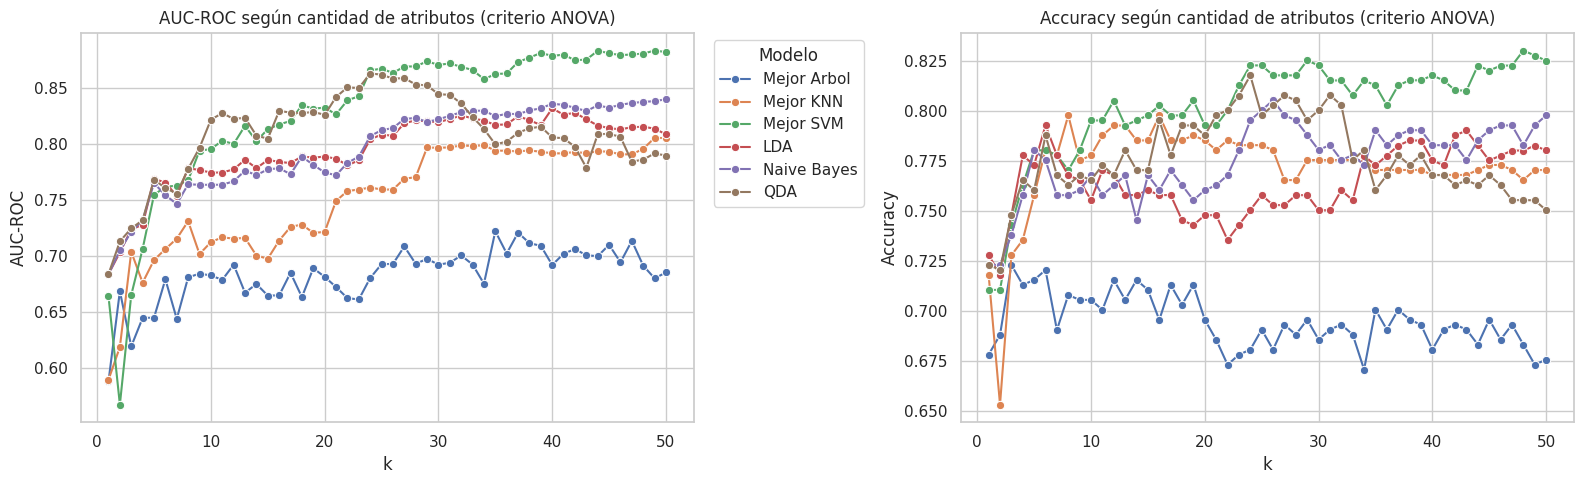

In [ ]:
df_plot = df_scores.melt(id_vars=['k', 'Modelo'], value_vars=['AUCROC', 'Accuracy'], var_name='Metrica', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

sns.lineplot(
    data=df_plot[df_plot['Metrica'] == 'AUCROC'],
    x='k',
    y='Score',
    hue='Modelo',
    marker='o',
    ax=axes[0]
 )
axes[0].set_title('AUC-ROC según cantidad de atributos (criterio ANOVA)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('AUC-ROC')

sns.lineplot(
    data=df_plot[df_plot['Metrica'] == 'Accuracy'],
    x='k',
    y='Score',
    hue='Modelo',
    marker='o',
    ax=axes[1]
 )
axes[1].set_title('Accuracy según cantidad de atributos (criterio ANOVA)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Accuracy')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend_.remove()
axes[0].legend(handles, labels, title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
mejor_fila_anova = df_scores.loc[df_scores['AUCROC'].idxmax()]
mejor_k_anova = int(mejor_fila_anova['k'])

selector = SelectKBest(score_func=f_classif, k=mejor_k_anova)
selector.fit(X, y)
atributos_seleccionados_anova = X.columns[selector.get_support()].tolist()

X_train_anova = df[atributos_seleccionados_anova]
X_control_anova = df_control[atributos_seleccionados_anova]

df_mejor_modelo_anova = evaluar_modelos_en_control(
    modelos,
    X_train_anova,
    y,
    X_control_anova,
    df_control['target']
)

df_mejor_modelo_anova

,Modelo,Accuracy (control),Accuracy Mayoritaria (control),Accuracy Minoritaria (control),AUC-PRC (control),AUC-ROC (control)
0,Mejor Arbol,0.555556,61.97,39.29,0.306519,0.497988
1,Mejor KNN,0.717172,88.73,28.57,0.497256,0.707746
2,Mejor SVM,0.767677,87.32,50.00,0.708314,0.831992
3,LDA,0.696970,85.92,28.57,0.555153,0.696680
4,Naive Bayes,0.727273,84.51,42.86,0.652501,0.791751
5,QDA,0.818182,100.00,35.71,0.868082,0.913481
